# NLP Preprocessing and Text Classification

**Name : Aniket Patil**

**Batch : DL2**

**Course : Deep Learning**

**PRN : 202301040248**



## Objective
Implement NLP preprocessing techniques and build a text classification model.

## Learning Outcomes
- Tokenization
- Stopword Removal
- Stemming & Lemmatization
- TF-IDF & Count Vectorizer
- Model Building & Evaluation

## 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string
import os

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download all required NLTK resources
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load Dataset

### Bundled Dataset — `sentiment_dataset.csv`
A ready-to-run **Sentiment Analysis** dataset is included alongside this notebook (`sentiment_dataset.csv`).  
It contains **160 labelled sentences** (80 positive, 80 negative) covering product reviews, customer service, and app feedback.

| Column | Description |
|--------|-------------|
| `text`  | Raw review sentence |
| `label` | `1` = Positive, `0` = Negative |

---

**Want to use your own data?**  
Just change `FILE_PATH`, `TEXT_COLUMN`, and `LABEL_COLUMN` below.  
Both **CSV** and **Excel (.xlsx / .xls)** are supported.

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# CONFIGURATION
# The bundled dataset is pre-filled — just run this cell as-is.
# To use your own file, change the three variables below.
# ─────────────────────────────────────────────────────────────────────
FILE_PATH    = 'sentiment_dataset.csv'  # bundled dataset (CSV or Excel path)
TEXT_COLUMN  = 'text'                   # column containing raw text
LABEL_COLUMN = 'label'                  # column containing class label
# ─────────────────────────────────────────────────────────────────────

def load_dataset(file_path: str) -> pd.DataFrame:
    """Load a CSV or Excel file into a DataFrame."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: '{file_path}'")

    ext = os.path.splitext(file_path)[1].lower()
    if ext == '.csv':
        return pd.read_csv(file_path)
    elif ext in ('.xlsx', '.xls'):
        return pd.read_excel(file_path)
    else:
        raise ValueError(f"Unsupported file type '{ext}'. Use .csv, .xlsx, or .xls")

df = load_dataset(FILE_PATH)

# Validate that the required columns exist
missing = [c for c in [TEXT_COLUMN, LABEL_COLUMN] if c not in df.columns]
if missing:
    raise KeyError(
        f"Column(s) {missing} not found.\n"
        f"Available columns: {df.columns.tolist()}"
    )

# Keep only the relevant columns and rename for downstream consistency
df = df[[TEXT_COLUMN, LABEL_COLUMN]].rename(
    columns={TEXT_COLUMN: 'text', LABEL_COLUMN: 'label'}
)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded: 160 rows, 2 columns


,text,label
0,"I absolutely love this product, it works perfe...",1
1,"Amazing quality and fast delivery, very happy ...",1
2,"Excellent customer service, they resolved my i...",1
3,"This is the best phone I have ever owned, high...",1
4,Outstanding performance and great value for th...,1


## 3. Data Exploration

Shape: (160, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    160 non-null    object
 1   label   160 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.6+ KB

Missing Values:
text     0
label    0
dtype: int64

Label Distribution:
label
1    80
0    80
Name: count, dtype: int64


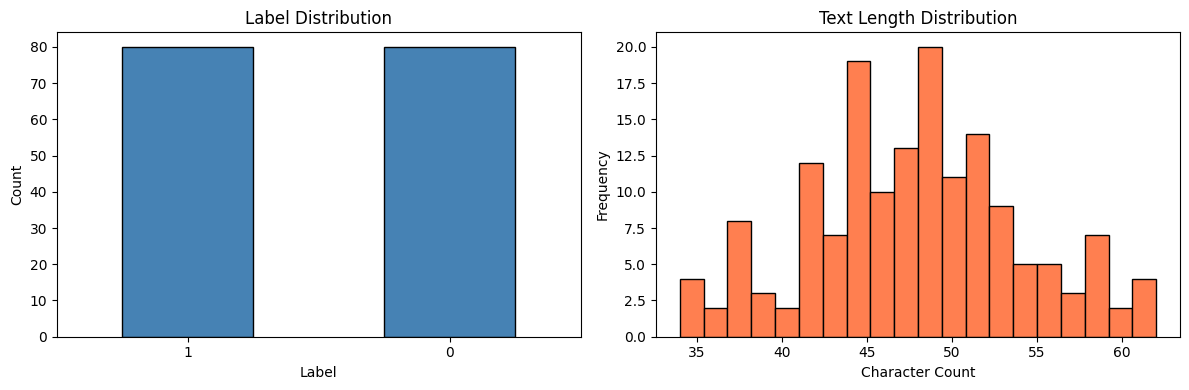

In [ ]:
print("Shape:", df.shape)
print()
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nLabel Distribution:")
print(df['label'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label count
df['label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Label Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Text length distribution
df['text_length'] = df['text'].astype(str).apply(len)
axes[1].hist(df['text_length'], bins=20, color='coral', edgecolor='black')
axes[1].set_title('Text Length Distribution')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 4. Text Preprocessing

### 4.0 Handle Missing / Non-string Values

In [ ]:
before = len(df)
df.dropna(subset=['text', 'label'], inplace=True)
df['text'] = df['text'].astype(str)
df.reset_index(drop=True, inplace=True)
print(f"Rows before: {before} | Rows after dropping NaN: {len(df)}")

Rows before: 160 | Rows after dropping NaN: 160


### 4.1 Lowercase, Punctuation & Special-Character Removal

In [ ]:
def clean_text(text: str) -> str:
    """Lowercase, strip URLs, punctuation, digits, and extra whitespace."""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)          # remove URLs
    text = re.sub(r'<.*?>', '', text)                       # remove HTML tags
    text = text.translate(str.maketrans('', '', string.punctuation))  # punctuation
    text = re.sub(r'\d+', '', text)                         # digits
    text = re.sub(r'\s+', ' ', text).strip()               # extra spaces
    return text

df['text'] = df['text'].apply(clean_text)
df.head()

,text,label,text_length
0,i absolutely love this product it works perfectly,1,51
1,amazing quality and fast delivery very happy w...,1,62
2,excellent customer service they resolved my is...,1,62
3,this is the best phone i have ever owned highl...,1,58
4,outstanding performance and great value for th...,1,53


### 4.2 Tokenization

In [ ]:
df['tokens'] = df['text'].apply(word_tokenize)
df[['text', 'tokens']].head()

,text,tokens
0,i absolutely love this product it works perfectly,"[i, absolutely, love, this, product, it, works..."
1,amazing quality and fast delivery very happy w...,"[amazing, quality, and, fast, delivery, very, ..."
2,excellent customer service they resolved my is...,"[excellent, customer, service, they, resolved,..."
3,this is the best phone i have ever owned highl...,"[this, is, the, best, phone, i, have, ever, ow..."
4,outstanding performance and great value for th...,"[outstanding, performance, and, great, value, ..."


### 4.3 Stopword Removal

In [ ]:
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda tokens: [w for w in tokens if w not in stop_words and len(w) > 1]
)

df[['text', 'tokens']].head()

,text,tokens
0,i absolutely love this product it works perfectly,"[absolutely, love, product, works, perfectly]"
1,amazing quality and fast delivery very happy w...,"[amazing, quality, fast, delivery, happy, purc..."
2,excellent customer service they resolved my is...,"[excellent, customer, service, resolved, issue..."
3,this is the best phone i have ever owned highl...,"[best, phone, ever, owned, highly, recommend]"
4,outstanding performance and great value for th...,"[outstanding, performance, great, value, price]"


### 4.4 Stemming

In [ ]:
stemmer = PorterStemmer()

df['stemmed'] = df['tokens'].apply(
    lambda tokens: [stemmer.stem(w) for w in tokens]
)

df[['tokens', 'stemmed']].head()

,tokens,stemmed
0,"[absolutely, love, product, works, perfectly]","[absolut, love, product, work, perfectli]"
1,"[amazing, quality, fast, delivery, happy, purc...","[amaz, qualiti, fast, deliveri, happi, purchas]"
2,"[excellent, customer, service, resolved, issue...","[excel, custom, servic, resolv, issu, immedi]"
3,"[best, phone, ever, owned, highly, recommend]","[best, phone, ever, own, highli, recommend]"
4,"[outstanding, performance, great, value, price]","[outstand, perform, great, valu, price]"


### 4.5 Lemmatization  *(used for final clean_text)*

In [ ]:
lemmatizer = WordNetLemmatizer()

df['lemmatized'] = df['tokens'].apply(
    lambda tokens: [lemmatizer.lemmatize(w) for w in tokens]
)

# Rejoin tokens into a clean string for vectorization
df['clean_text'] = df['lemmatized'].apply(lambda tokens: ' '.join(tokens))

# Drop rows where cleaning left an empty string
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

print(f"Rows remaining after preprocessing: {len(df)}")
df[['text', 'clean_text', 'label']].head()

Rows remaining after preprocessing: 160


,text,clean_text,label
0,i absolutely love this product it works perfectly,absolutely love product work perfectly,1
1,amazing quality and fast delivery very happy w...,amazing quality fast delivery happy purchase,1
2,excellent customer service they resolved my is...,excellent customer service resolved issue imme...,1
3,this is the best phone i have ever owned highl...,best phone ever owned highly recommend,1
4,outstanding performance and great value for th...,outstanding performance great value price,1


## 5. Text Vectorization

### 5.1 Count Vectorizer

In [ ]:
count_vectorizer = CountVectorizer()
X_count = count_vectorizer.fit_transform(df['clean_text'])

print("Count Vectorizer shape:", X_count.shape)
print("Vocabulary size:", len(count_vectorizer.vocabulary_))

Count Vectorizer shape: (160, 390)
Vocabulary size: 390


### 5.2 TF-IDF Vectorizer  *(used for modelling)*

In [ ]:
tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df['clean_text'])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (160, 390)


## 6. Train / Test Split

In [ ]:
y = df['label']

# Use stratify only when every class has at least 2 samples
min_class_count = y.value_counts().min()
use_stratify = min_class_count >= 2

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y if use_stratify else None
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
if not use_stratify:
    print("Note: stratify disabled — some classes have fewer than 2 samples.")

Train size: 128 | Test size: 32


## 7. Model Building

### 7.1 Naive Bayes

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
pred_nb = nb_model.predict(X_test)
print("Naive Bayes trained.")

Naive Bayes trained.


### 7.2 Logistic Regression

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
pred_lr = lr_model.predict(X_test)
print("Logistic Regression trained.")

Logistic Regression trained.


## 8. Model Evaluation

Model : Naive Bayes
Accuracy : 0.7812

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        16
           1       0.76      0.81      0.79        16

    accuracy                           0.78        32
   macro avg       0.78      0.78      0.78        32
weighted avg       0.78      0.78      0.78        32



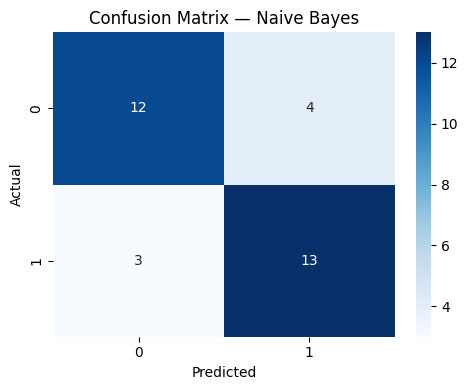

Model : Logistic Regression
Accuracy : 0.8750

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        16
           1       0.93      0.81      0.87        16

    accuracy                           0.88        32
   macro avg       0.88      0.88      0.87        32
weighted avg       0.88      0.88      0.87        32



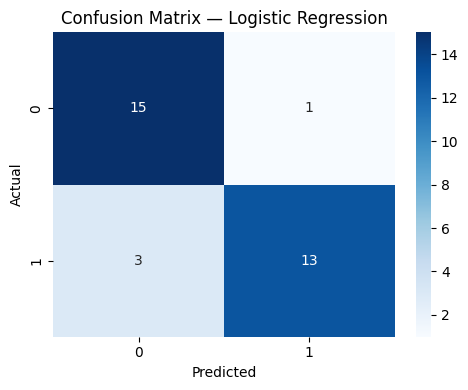

In [ ]:
def evaluate_model(name, y_true, y_pred):
    """Print metrics and plot confusion matrix."""
    acc = accuracy_score(y_true, y_pred)
    print(f"{'='*50}")
    print(f"Model : {name}")
    print(f"Accuracy : {acc:.4f}")
    print()
    print("Classification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

evaluate_model('Naive Bayes',         y_test, pred_nb)
evaluate_model('Logistic Regression', y_test, pred_lr)

### 8.1 Model Comparison

              Model  Accuracy
Logistic Regression   0.87500
        Naive Bayes   0.78125


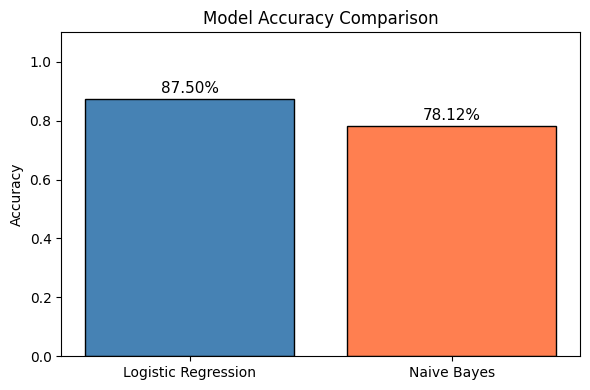

In [ ]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, pred_nb),
        accuracy_score(y_test, pred_lr)
    ]
})

results.sort_values('Accuracy', ascending=False, inplace=True)
print(results.to_string(index=False))

plt.figure(figsize=(6, 4))
bars = plt.bar(results['Model'], results['Accuracy'], color=['steelblue', 'coral'], edgecolor='black')
plt.ylim(0, 1.1)
for bar, acc in zip(bars, results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f'{acc:.2%}', ha='center', fontsize=11)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

## 9. Prediction on New Data

New text must go through **the same preprocessing pipeline** before vectorization.

In [ ]:
def preprocess_input(raw_texts: list) -> list:
    """Apply the full preprocessing pipeline to a list of raw strings."""
    processed = []
    for text in raw_texts:
        text = clean_text(str(text))
        tokens = word_tokenize(text)
        tokens = [w for w in tokens if w not in stop_words and len(w) > 1]
        tokens = [lemmatizer.lemmatize(w) for w in tokens]
        processed.append(' '.join(tokens))
    return processed


# ── Add your own sentences here ──
new_samples = [
    "This product is absolutely amazing!",
    "Worst experience I have ever had.",
    "Quite good, will recommend to friends.",
]

processed_samples = preprocess_input(new_samples)
sample_vec = tfidf.transform(processed_samples)

nb_preds = nb_model.predict(sample_vec)
lr_preds = lr_model.predict(sample_vec)

results_df = pd.DataFrame({
    'Text': new_samples,
    'NB Prediction': nb_preds,
    'LR Prediction': lr_preds
})

print(results_df.to_string(index=False))

                                  Text  NB Prediction  LR Prediction
   This product is absolutely amazing!              1              1
     Worst experience I have ever had.              0              0
Quite good, will recommend to friends.              1              1


## 10. Conclusion

| Step | Details |
|---|---|
| **Data Loading** | CSV and Excel files supported via `load_dataset()` |
| **Cleaning** | Lowercase, URL/HTML removal, punctuation & digit stripping |
| **Tokenization** | NLTK `word_tokenize` |
| **Stopword Removal** | NLTK English stopwords + single-character tokens |
| **Stemming** | Porter Stemmer (for reference) |
| **Lemmatization** | WordNet Lemmatizer (used in final feature text) |
| **Vectorization** | CountVectorizer & TF-IDF |
| **Models** | Multinomial Naive Bayes & Logistic Regression |
| **Evaluation** | Accuracy, Classification Report, Confusion Matrix, Comparison Bar Chart |
| **Inference** | `preprocess_input()` ensures new text follows the same pipeline |